In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

caminho = "salvamentos/tudo_ai.csv"

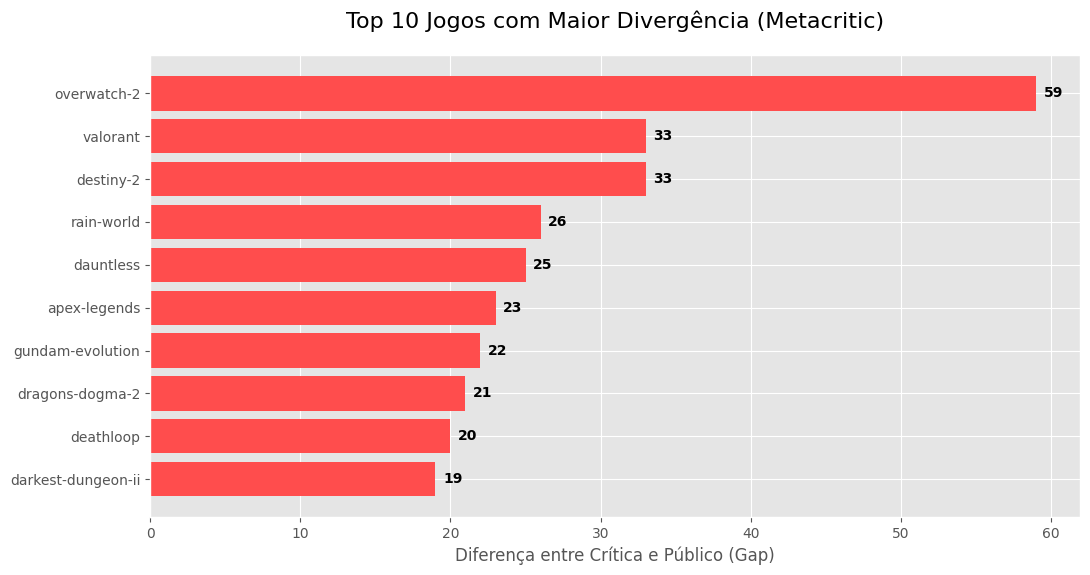

In [6]:

%matplotlib inline

df = pd.read_csv(caminho)

df['gap'] = pd.to_numeric(df['gap'], errors='coerce').fillna(0)
df['nota_publica'] = pd.to_numeric(df['nota_publica'], errors='coerce').fillna(0)
df['nota_critica'] = pd.to_numeric(df['nota_critica'], errors='coerce').fillna(0)

top_10 = df.nlargest(10, 'gap')

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#ff4d4d' if g > 15 else '#ffcc00' for g in top_10['gap']]
    
bars = ax.barh(top_10['jogo'], top_10['gap'], color=colors)
    
ax.set_title('Top 10 Jogos com Maior Divergência (Metacritic)', fontsize=16, pad=20)
ax.set_xlabel('Diferença entre Crítica e Público (Gap)', fontsize=12)
ax.invert_yaxis() 

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{int(width)}', va='center', fontweight='bold')

plt.show()

C:\Users\teecno\AppData\Local\Temp\ipykernel_1992\3994673865.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=empresa_counts.values, y=empresa_counts.index, palette="viridis")


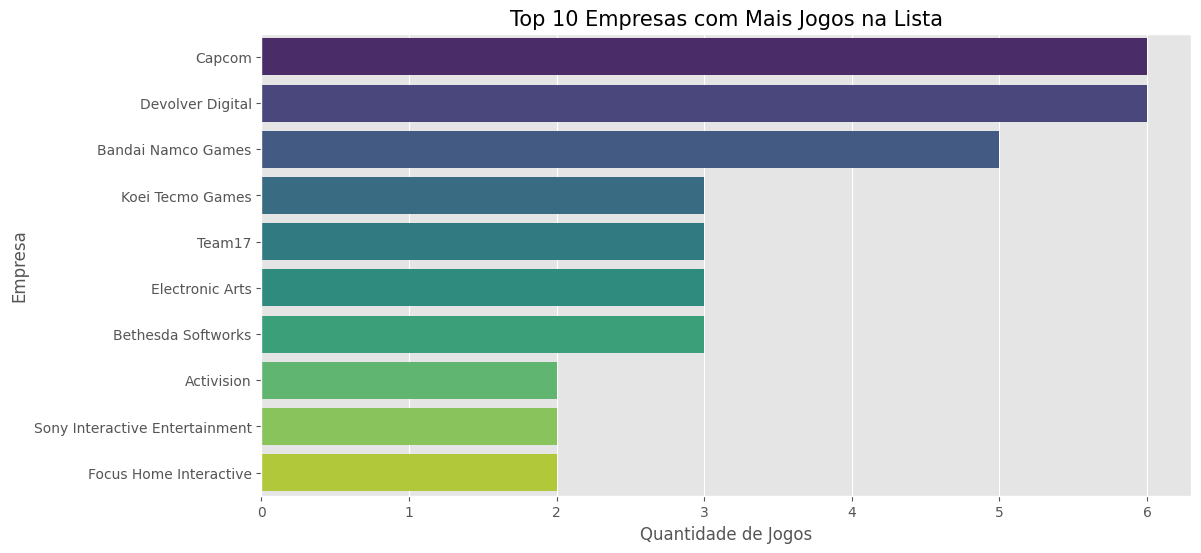

In [7]:
plt.figure(figsize=(12, 6))
empresa_counts = df["empresa"].value_counts().head(10)

sns.barplot(x=empresa_counts.values, y=empresa_counts.index, palette="viridis")

plt.title("Top 10 Empresas com Mais Jogos na Lista", fontsize=15)
plt.xlabel("Quantidade de Jogos")
plt.ylabel("Empresa")
plt.show()

C:\Users\teecno\AppData\Local\Temp\ipykernel_1992\2862681518.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_unanimidade, x="media_notas", y="jogo", palette="magma")


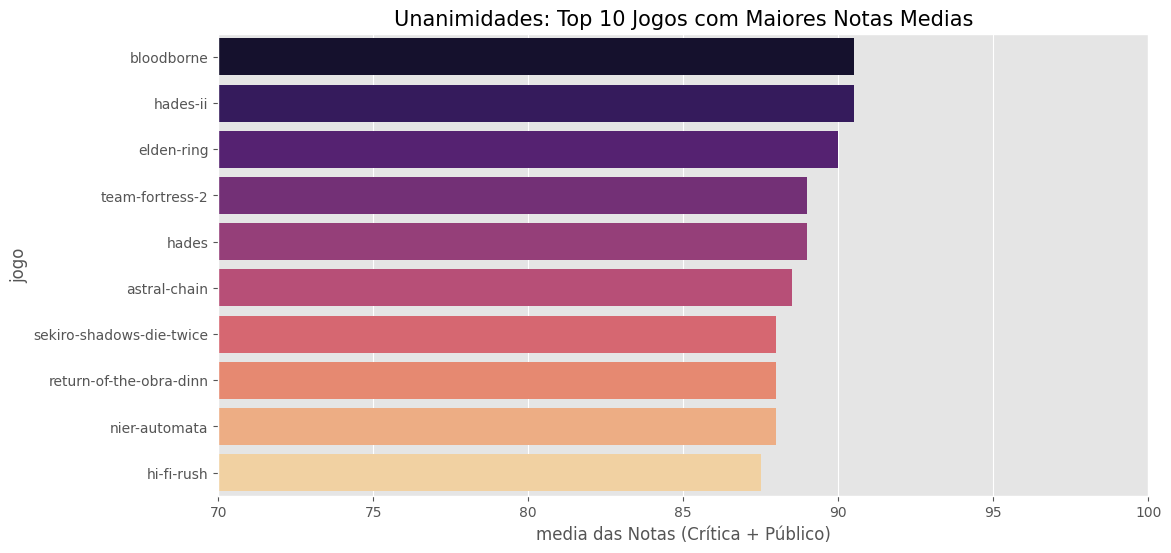

In [8]:
df["media_notas"] = (df["nota_critica"] + df["nota_publica"]) / 2
top_unanimidade = df.nlargest(10, "media_notas")

plt.figure(figsize=(12, 6))
sns.barplot(data=top_unanimidade, x="media_notas", y="jogo", palette="magma")

plt.title("Unanimidades: Top 10 Jogos com Maiores Notas Medias", fontsize=15)
plt.xlabel("media das Notas (Crítica + Público)")
plt.xlim(70, 100)
plt.show()

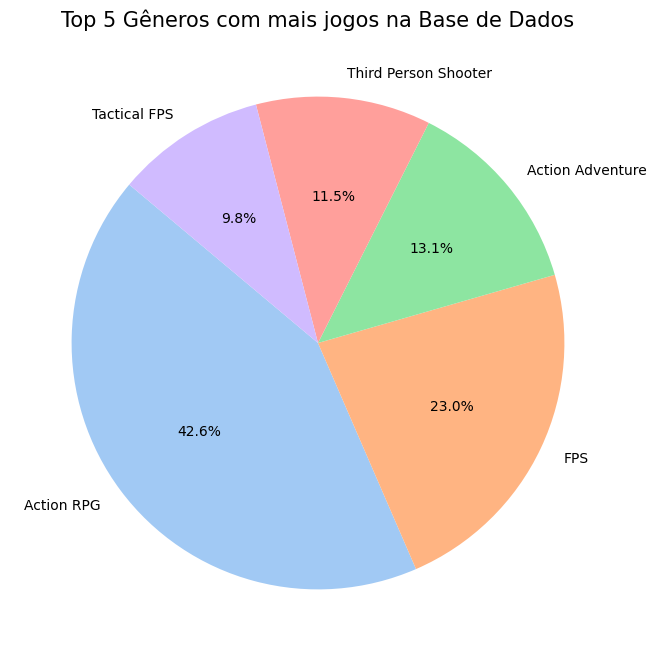

In [9]:
plt.figure(figsize=(8, 8))

genero_counts = df["genero"].value_counts().head(5)

plt.pie(
    genero_counts,
    labels=genero_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel"),
)
plt.title("Top 5 Gêneros com mais jogos na Base de Dados", fontsize=15)
plt.show()